<a href="https://colab.research.google.com/github/ShamimtheAnalyst/Crash-Course/blob/main/Chi_Squared_Test_of_Independence_Masterclass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚢 Titanic Survival & Social Stratification: Chi-Squared Test of Independence Masterclass

### নোটবুক পরিচিতি (Metadata)

* **Aim:** টাইটানিক দুর্যোগের ডেটা ব্যবহার করে দেখা যে, যাত্রীদের টিকিট ক্লাস (1st, 2nd, 3rd) এবং তাদের বেঁচে যাওয়ার (Survival) মধ্যে কোনো বাস্তব সামাজিক বা অর্থনৈতিক সম্পর্ক ছিল কি না।
* **Concept:** **Chi-Squared Test of Independence** দুটি ক্যাটাগরিক্যাল ভ্যারিয়েবলের মধ্যকার সম্পর্ক পরীক্ষা করে। এটি দেখে যে বাস্তব ডেটা (Observed) এবং সম্পূর্ণ স্বাধীন অবস্থার ডেটার (Expected) মধ্যে কোনো বড় পার্থক্য আছে কি না।
* **Key Skills:** Data Uncounting, Relative Stacked Bar Chart, এবং Chi-Square Statistics Interpretation।

---

## কেন Chi-Squared Test অফ ইন্ডিপেন্ডেন্স ব্যবহার করবেন?

১. **স্বাধীন বনাম নির্ভরশীল:** দুটি বিষয়ের সম্পর্ক কি কেবল কাকতালীয় (Independent) নাকি একটির ওপর অন্যটি নির্ভরশীল (Dependent), তা গাণিতিকভাবে প্রমাণ করতে।
২. **ক্যাটাগরিক্যাল ডেটা অ্যানালাইসিস:** যখন ডেটা সংখ্যাবাচক না হয়ে গ্রুপ বা শ্রেণীবাচক (যেমন: বেঁচে যাওয়া/মারা যাওয়া, ক্লাসের ধরণ) হয়, তখন এটি সেরা টুল।

---


## ১. এনভায়রনমেন্ট সেটআপ (Setup)

প্রথমে প্রয়োজনীয় লাইব্রেরিগুলো লোড করে নেওয়া যাক।

In [3]:
# Load Core Libraries
library(tidyverse)

## ২. ডেটা প্রিপারেশন (Data Loading & Wrangling)

R-এর বিল্ট-ইন `Titanic` ডাটাসেটটি একটি টেবিল ফরম্যাটে থাকে। আমরা ক্রু-মেম্বারদের বাদ দিয়ে শুধু যাত্রীদের ডেটাকে একক রো বা লাইনে রূপান্তর (Expand) করব।


In [4]:
# ডেটা ক্লিন, এক্সপ্যান্ড এবং ফিল্টার করা
titanic_df <- Titanic |>
  as_tibble() |>
  uncount(n) |>  # compressed টেবিলকে একক রো-তে রূপান্তর
  filter(Class != "Crew") # শুধু সাধারণ প্যাসেঞ্জারদের রাখা হলো


In [5]:
# ডেটার এক পলক
glimpse(titanic_df)

Rows: 1,316
Columns: 4
$ Class    <chr> "3rd", "3rd", "3rd", "3rd", "3rd", "3rd", "3rd", "3rd", "3rd"…
$ Sex      <chr> "Male", "Male", "Male", "Male", "Male", "Male", "Male", "Male…
$ Age      <chr> "Child", "Child", "Child", "Child", "Child", "Child", "Child"…
$ Survived <chr> "No", "No", "No", "No", "No", "No", "No", "No", "No", "No", "…


## ৩. ডেটা ভিজ্যুয়ালাইজেশন ও সামারি টেবিল

পরিসংখ্যানের জটিল ম্যাথ শুরু করার আগে ডেটার ট্রেন্ড বা অনুপাত দেখে নেওয়া জরুরি।

### ধাপ ১: রিলেটিভ-স্ট্যাকড বার চার্ট (Proportional Plot)

আমরা প্রতিটি ক্লাসের বেঁচে যাওয়া এবং মারা যাওয়া যাত্রীদের অনুপাত দেখব।

In [6]:
# লেবেল পজিশনের জন্য ইন্টারনাল ম্যাট্রিক্স ক্যালকুলেট করা
titanic_summary <- titanic_df |>
  count(Class, Survived) |>
  group_by(Class) |>
  mutate(
    total = sum(n),
    prop = n / total,
    cumulative = cumsum(prop),
    label_pos = cumulative - (prop / 2)
  ) |>
  ungroup()

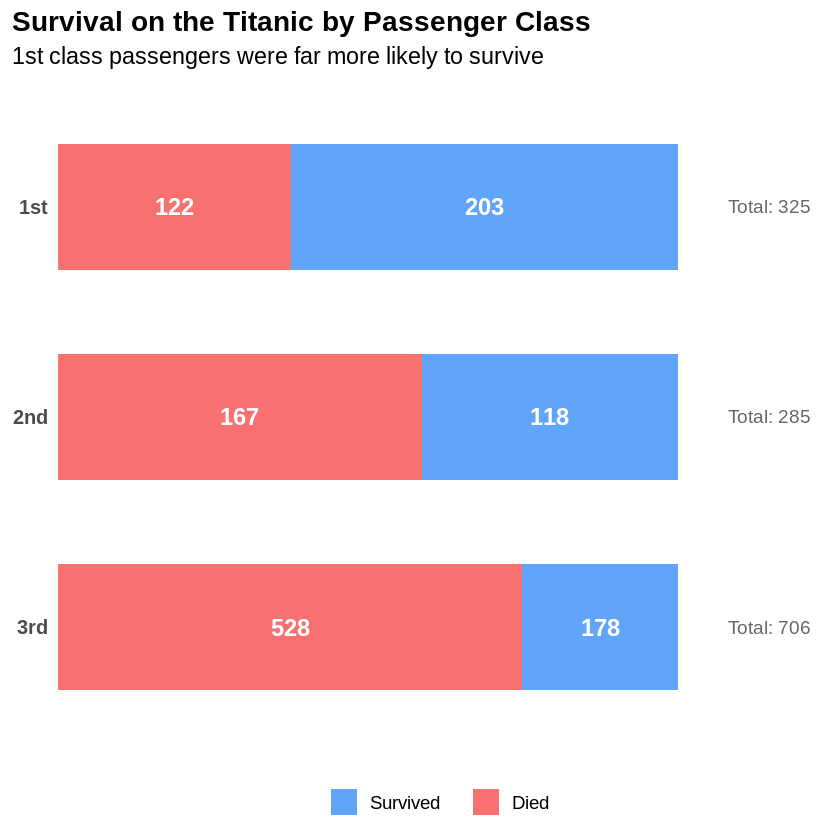

In [7]:
# প্লট তৈরি
titanic_summary |>
  ggplot(aes(x = prop, y = fct_rev(Class), fill = fct_rev(Survived))) +
  geom_col(width = 0.6) +
  geom_text(aes(x = label_pos, label = n), colour = "white", fontface = "bold", size = 5) +
  geom_text(aes(x = 1.08, label = ifelse(Survived == "Yes", paste("Total:", total), "")),
            hjust = 0, colour = "grey40", size = 4) +
  scale_fill_manual(
    values = c("Yes" = "#60a5fa", "No" = "#f87171"),
    labels = c("Survived", "Died"),
    breaks = c("Yes", "No")
  ) +
  scale_x_continuous(expand = expansion(mult = c(0, 0.15)), labels = NULL) +
  labs(
    title = "Survival on the Titanic by Passenger Class",
    subtitle = "1st class passengers were far more likely to survive",
    x = NULL, y = NULL, fill = NULL
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "bottom",
    panel.grid = element_blank(),
    axis.text.y = element_text(face = "bold", size = 12),
    plot.title = element_text(face = "bold"),
    plot.title.position = "plot"
  )


## ৪. Chi-Squared Test সম্পাদন

ভিজ্যুয়ালাইজেশনে স্পষ্ট বৈষম্য দেখা গেলেও, আমাদের গাণিতিকভাবে প্রমাণ করতে হবে যে এটি কেবল ভাগ্যের ফেরে বা দৈবচয়ন (Random chance) কারণে ঘটেনি।

In [8]:
# Conduct the Test of Independence
titanic_df |>
  select(Class, Survived) |>
  table() |>
  chisq.test()



	Pearson's Chi-squared test

data:  table(select(titanic_df, Class, Survived))
X-squared = 133.05, df = 2, p-value < 2.2e-16


## ৫. ফলাফলের বিস্তারিত ইন্টারপ্রিটেশন (Interpretation)

টেস্ট রান করার পর আমরা ৩টি প্রধান মান পাই, যা একাডেমিক পেপার বা রিপোর্টে লিখতে হয়:

### ১. টেস্ট স্ট্যাটিস্টিক ($X^2 = 133.05$)

* **ব্যাখ্যা:** এটি মূলত একটি "দূরত্ব মাপার ট্র্যাকার"। আপনার বাস্তব ডেটা এবং তাত্ত্বিক স্বাধীন ডেটার (যেখানে ক্লাসের কোনো প্রভাব থাকার কথা ছিল না) মধ্যকার ব্যবধান কত বেশি, তা এই মান দিয়ে বোঝা যায়। $133.05$ একটি বিশাল মান, যা নির্দেশ করে যে বাস্তব চিত্রটি সাধারণ সম্ভাবনা থেকে অনেক দূরে ছিল।

### ২. ডিগ্রিজ অব ফ্রিডম ($df = 2$)

* **গাণিতিক সূত্র:** $df = (\text{Rows} - 1) \times (\text{Columns} - 1) = (3 - 1) \times (2 - 1) = 2$
* **ব্যাখ্যা:** এটি চি-স্কয়ার ডিস্ট্রিবিউশন কার্ভের সঠিক আকৃতি নির্ধারণ করে, যার ওপর ভিত্তি করে সিগনিফিকেন্স লেভেল মাপা হয়।

### ৩. পি-ভ্যালু ($p \text{-value} < 2.2 \times 10^{-16}$)

* **ব্যাখ্যা:** এটি আমাদের সিগনিফিকেন্সের চূড়ান্ত প্রমাণ। যেহেতু এই মানটি আমাদের স্ট্যান্ডার্ড থ্রেশহোল্ড $0.05$-এর চেয়ে অনেক অনেক কম, তাই আমরা **Null Hypothesis ($H_0$)** সরাসরি রিজেক্ট করছি।

---

## চূড়ান্ত সিদ্ধান্ত (Conclusion)

টাইটানিক জাহাজে যাত্রীদের টিকিট ক্লাস এবং তাদের বেঁচে যাওয়ার হারের মধ্যে একটি অত্যন্ত শক্তিশালী এবং পরিসংখ্যানগতভাবে সিগনিফিকেন্ট সম্পর্ক ছিল। টিকিট ক্লাস কেবল একটি সাধারণ সংখ্যা ছিল না, বরং এটি কাঠামোগতভাবে একজন যাত্রীর লাইফবোটে ওঠার সুযোগ নির্ধারণ করে দিয়েছিল। প্রথম শ্রেণীর যাত্রীদের তুলনায় তৃতীয় শ্রেণীর যাত্রীদের বেঁচে থাকার সম্ভাবনা ছিল অত্যন্ত সংকুচিত।

---

### এক নজরে থাম্ব রুল (Analytical Rule of Thumb):

| মেট্রিক | উচ্চ মান (High Value) | নিম্ন মান (Low Value) |
| --- | --- | --- |
| **Chi-Square ($X^2$)** | র্যান্ডমনেস বা কাকতালীয় হওয়ার সম্ভাবনা নেই | বাস্তব ডেটা সম্পূর্ণ র্যান্ডম পরিস্থিতির সমান |
| **P-Value** | পরিসংখ্যানগতভাবে তাৎপর্যহীন (Noise) | পরিসংখ্যানগতভাবে অত্যন্ত তাৎপর্যপূর্ণ (Real Pattern) |

---